# CH4. Online Analysis

## Preamble

In [1]:
# Standard Library
import os
import sys
import time
from pathlib import Path

# Numerical Processing
import numpy as np

# SmartSim and SmartRedis
from smartsim import Experiment
from smartredis import Client

# Visualisation
import DataGraph as dg
import matplotlib.pyplot as plt

In [2]:
# Remove inherited Slurm environment from the interactive parent job
for key in list(os.environ):
    if key.startswith(("SLURM_", "SBATCH_", "SRUN_")):
        os.environ.pop(key)

### Directories

In [3]:
# Directory
PROJECT_DIR = Path("/scratch/project_2015384/Hanseul")
BASE_DIR = PROJECT_DIR / "Codes" / "SmartSim"
MAIN_DIR = BASE_DIR / "OnlineAnalysis"
SCRIPT_DIR = MAIN_DIR / "scripts"
OUTPUT_DIR = MAIN_DIR / "outputs"

for directory in [PROJECT_DIR, BASE_DIR, MAIN_DIR, SCRIPT_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    

### Configuration

In [4]:
# DataGraph Configuration
FIG_X, FIG_Y = 3.2, 2.5
FIGURE_SIZE = (FIG_X, FIG_Y)
PALETTE = dg.get_palette("OKABE_ITO")
dg.set_style(figure_size=FIGURE_SIZE)

In [5]:
# System configuration
SEED = 42
np.random.seed(SEED)
N_JOBS = len(list(os.sched_getaffinity(0)))

# SmartRedis configuration
REDIS_PORT = 2026

In [6]:
# ONNX configuration (Backend ONNX ver: 1.21.0 -> opset: 26, IR: 13)
OPSET_VERSION = 26
IR_VERSION = 13

### Visualisation Helpers

In [7]:
# von-Karman Plotting Functions
def plot_lattice_vorticity(timestep, ux, uy, cylinder):
    """Plot vorticity field of the lattice Boltzmann simulation."""
    ux[cylinder], uy[cylinder] = 0, 0
    vorticity = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) - \
                (np.roll(uy, -1, axis=1) - np.roll(uy, 1, axis=1))
    vorticity[cylinder] = np.nan

    fig, ax = plt.subplots(figsize=(FIG_X * 2, FIG_Y))
    cmap = plt.get_cmap("turbo").copy()
    cmap.set_bad(color="black")
    im = ax.imshow(vorticity, cmap=cmap, vmin=-0.02, vmax=0.02, origin="upper")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Vorticity")
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"Vorticity  —  timestep {timestep}", fontsize=13)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


def plot_lattice_norm(timestep, u, cylinder):
    """Plot velocity magnitude of the lattice Boltzmann simulation."""
    u_plot = u.copy()
    u_plot[cylinder] = np.nan

    fig, ax = plt.subplots(figsize=(FIG_X * 2, FIG_Y))
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad(color="black")
    im = ax.imshow(u_plot, cmap=cmap, origin="upper")
    fig.colorbar(im, ax=ax, shrink=0.8, label="|u|")
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"Velocity Magnitude  —  timestep {timestep}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


def plot_lattice_probes(timestep, probe_x, probe_y, probe_u):
    """Plot velocity vectors at probe locations."""
    speed = np.linalg.norm(probe_u, axis=2)

    fig, ax = plt.subplots(figsize=(FIG_X * 2, FIG_Y))
    q = ax.quiver(
        probe_x, probe_y,
        probe_u[:, :, 0], probe_u[:, :, 1],
        speed, cmap="magma", scale=7,
        pivot="mid", angles="uv", width=0.003
    )
    fig.colorbar(q, ax=ax, shrink=0.8, label="|u|")
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xlim([0, 399]); ax.set_ylim([0, 99])
    ax.set_title(f"Velocity Field  —  timestep {timestep}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

In [22]:
# Lid-Driven Cavity Plotting Functions
def plot_cavity_fields(step, sim_time, u_c, v_c, speed, p, nx, ny):
    """Plot velocity magnitude, streamlines, and pressure for the cavity."""
    x = np.linspace(0.5 / nx, 1.0 - 0.5 / nx, nx)
    y = np.linspace(0.5 / ny, 1.0 - 0.5 / ny, ny)
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(1, 3, figsize=(FIG_X * 2.5, FIG_Y))
    fig.suptitle(f"Lid-Driven Cavity (Re={Re})  —  step {step}, t = {sim_time:.4f}")

    # Velocity magnitude
    cf0 = axes[0].contourf(X, Y, speed, 50, cmap='turbo')
    fig.colorbar(cf0, ax=axes[0])
    axes[0].set_title('Velocity Magnitude')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
    axes[0].set_aspect('equal')

    # Streamlines
    axes[1].streamplot(x, y, u_c, v_c, density=2, color=PALETTE["black"], linewidth=0.5)
    axes[1].set_title('Streamlines')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
    axes[1].set_aspect('equal')

    # Pressure
    cf2 = axes[2].contourf(X, Y, p, 50, cmap='turbo')
    fig.colorbar(cf2, ax=axes[2])
    axes[2].set_title('Pressure')
    axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
    axes[2].set_aspect('equal')

    plt.tight_layout()
    plt.show()


def plot_centreline(step, u_c, ny):
    """Plot u-velocity along the vertical centreline."""
    y = np.linspace(0.5 / ny, 1.0 - 0.5 / ny, ny)
    j_mid = u_c.shape[1] // 2

    fig, ax = plt.subplots(figsize=(FIG_X, FIG_Y))
    ax.plot(u_c[:, j_mid], y, c=PALETTE["blue"], ms=3)
    ax.set_xlabel('u')
    ax.set_ylabel('y')
    ax.set_title(f'Centreline u-velocity  (step {step})')
    ax.grid(True)
    ax.set_box_aspect(1)
    plt.tight_layout()
    plt.show()

## Online Processing in Local

### Von Karman

In [9]:
# Von Karman vortex street configuration
config_vk = {
    "x_res": 400,
    "y_res": 100,
    "tau": 0.55, # LBM relaxation time
    "steps": 3000, # Number of time steps
    "save_interval": 10, # Interval for saving data
}

config_vk.update({
    "exp_name": "von_karman",
    "producer_path": str(SCRIPT_DIR / "producer_vk.py"),
    "exp_dir": str(OUTPUT_DIR / "von_karman"),
})

Path(config_vk["exp_dir"]).mkdir(parents=True, exist_ok=True)

In [10]:
# Initialise the SmartSim experiment
exp = Experiment(name=config_vk["exp_name"], 
                 exp_path=config_vk["exp_dir"],
                 launcher="local")

# Define orchestrator database
db = exp.create_database(
    db_nodes=1,
    port=REDIS_PORT,
    interface="lo", # lo, ib0, enp1s0f0, enp1s0f1
    inter_op_threads=1,
    intra_op_threads=1,
)

# Set up  and start the experiment
exp.generate(db, overwrite=True)
exp.start(db, block=False)

# Open a client connection to the orchestrator database
client = Client(
    address=db.get_address()[0],
    cluster=False,
)

SmartRedis Library@09-11-52:WARNING: Environment variable SR_LOG_FILE is not set. Defaulting to stdout
SmartRedis Library@09-11-52:WARNING: Environment variable SR_LOG_LEVEL is not set. Defaulting to INFO


In [11]:
# Create producer
producer_settings = exp.create_run_settings(
    exe=sys.executable,
    exe_args=[
        config_vk["producer_path"],
        "--x_res", str(config_vk["x_res"]),
        "--y_res", str(config_vk["y_res"]),
        "--tau", str(config_vk["tau"]),
        "--steps", str(config_vk["steps"]),
        "--save_interval", str(config_vk["save_interval"]),
    ]
)

producer = exp.create_model(
    name="producer",
    run_settings=producer_settings,
)

# Start the producer
exp.generate(producer, overwrite=True)
exp.start(producer, block=False, summary=True)

09:11:52 rc5283 SmartSim[2080470:MainThread] INFO 

=== Launch Summary ===
Experiment: von_karman
Experiment Path: /scratch/project_2015384/Hanseul/Codes/SmartSim/OnlineAnalysis/outputs/von_karman
Launcher: local
Models: 1
Database Status: active

=== Models ===
producer
Executable: /scratch/project_2015384/Hanseul/Utilities/Python/PythonSmartSim/envs/PentagonToy-3.12-x64/bin/python
Executable Arguments: /scratch/project_2015384/Hanseul/Codes/SmartSim/OnlineAnalysis/scripts/producer_vk.py --x_res 400 --y_res 100 --tau 0.55 --steps 3000 --save_interval 10





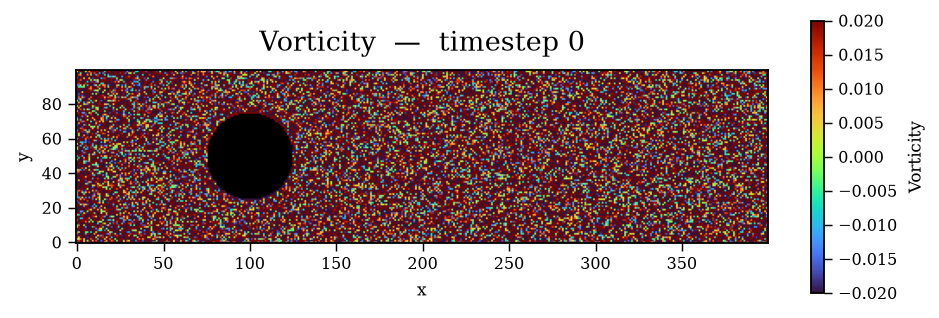

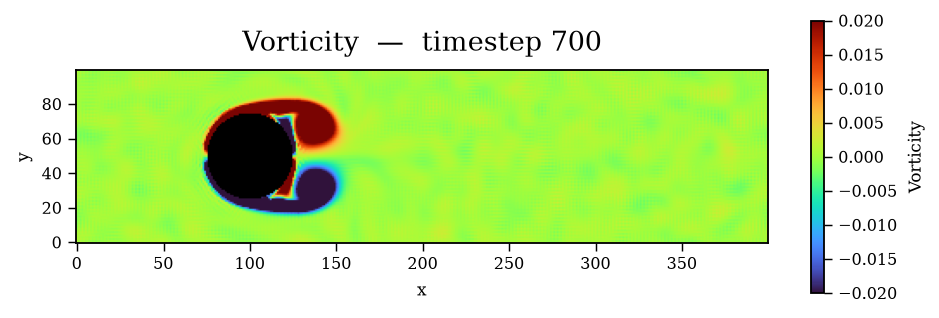

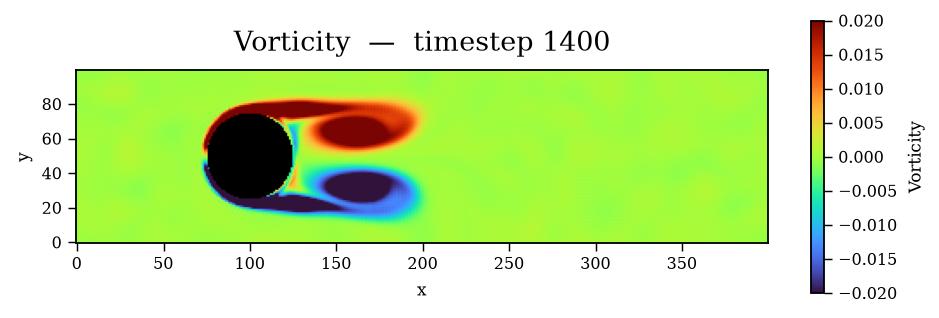

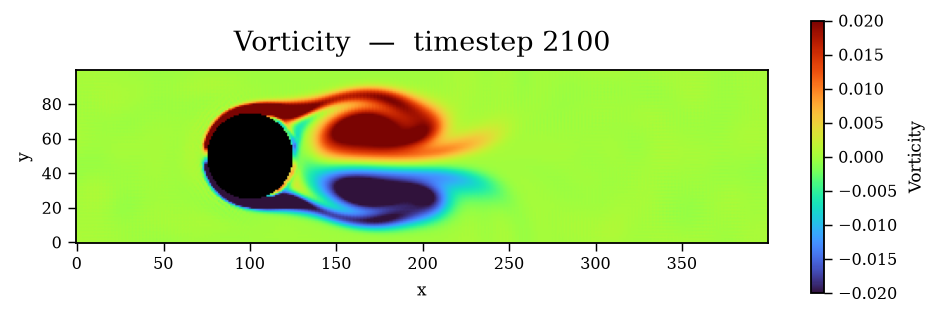

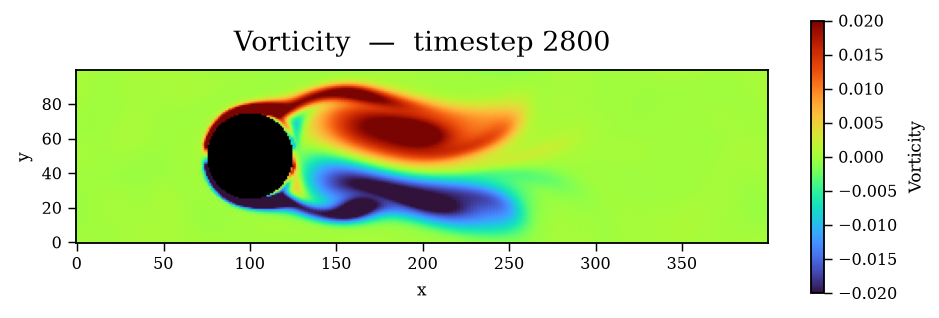

09:12:09 rc5283 SmartSim[2080470:JobManager] INFO producer(2081450): SmartSimStatus.STATUS_COMPLETED


In [12]:
# Get the cylinder location in the mesh
client.poll_key(f"cylinder", 300, 1000)
cylinder = client.get_tensor("cylinder").astype(bool)

# plot every 700th timestep
for i in range(0, config_vk["steps"], 700):
    client.poll_dataset(f"data_{i}", 300, 1000)
    dataset = client.get_dataset(f"data_{i}")
    ux, uy = dataset.get_tensor("ux"), dataset.get_tensor("uy")

    plot_lattice_vorticity(i, ux, uy, cylinder)

# Use the Experiment API to wait until the model is finished
while not exp.finished(producer):
    time.sleep(5)

In [ ]:
# Summarise the experiment results
print(exp.summary(style="rounded_grid"))

# Cleanup
print("\nExperiment completed. Cleaning up...")
exp.stop(db)
exp.stop(producer)
print("Done.")

### Lid-Driven Cavity

In [13]:
# LDC configuration
config_ldc = {
    "Re": 400.0,
    "nx": 64,
    "ny": 64,
    "nt": 5000,
    "endTime": 10.0,
    "save_interval": 100, # Interval for saving data
}

config_ldc.update({
    "exp_name": "lid_driven_cavity",
    "producer_path": str(SCRIPT_DIR / "producer_ldc.py"),
    "exp_dir": str(OUTPUT_DIR / "lid_driven_cavity"),
})

Path(config_ldc["exp_dir"]).mkdir(parents=True, exist_ok=True)

In [14]:
# Initialise the SmartSim experiment
exp = Experiment(name=config_ldc["exp_name"], 
                 exp_path=config_ldc["exp_dir"],
                 launcher="local")

# Define orchestrator database
db = exp.create_database(
    db_nodes=1,
    port=REDIS_PORT + 1,
    interface="lo", # lo, ib0, enp1s0f0, enp1s0f1
    inter_op_threads=1,
    intra_op_threads=1,
)

# Set up  and start the experiment
exp.generate(db, overwrite=True)
exp.start(db, block=False)

# Open a client connection to the orchestrator database
client = Client(
    address=db.get_address()[0],
    cluster=False,
)

In [15]:
# Create producer
producer_settings = exp.create_run_settings(
    exe=sys.executable,
    exe_args=[
        config_ldc["producer_path"],
        "--Re", str(config_ldc["Re"]),
        "--nx", str(config_ldc["nx"]),
        "--ny", str(config_ldc["ny"]),
        "--nt", str(config_ldc["nt"]),
        "--endTime", str(config_ldc["endTime"]),
        "--save_interval", str(config_ldc["save_interval"])
    ]
)

producer = exp.create_model(
    name="producer",
    run_settings=producer_settings,
)

# Start the producer
exp.generate(producer, overwrite=True)
exp.start(producer, block=False, summary=True)

09:12:22 rc5283 SmartSim[2080470:MainThread] INFO 

=== Launch Summary ===
Experiment: lid_driven_cavity
Experiment Path: /scratch/project_2015384/Hanseul/Codes/SmartSim/OnlineAnalysis/outputs/lid_driven_cavity
Launcher: local
Models: 1
Database Status: active

=== Models ===
producer
Executable: /scratch/project_2015384/Hanseul/Utilities/Python/PythonSmartSim/envs/PentagonToy-3.12-x64/bin/python
Executable Arguments: /scratch/project_2015384/Hanseul/Codes/SmartSim/OnlineAnalysis/scripts/producer_ldc.py --Re 400.0 --nx 64 --ny 64 --nt 5000 --endTime 10.0 --save_interval 100





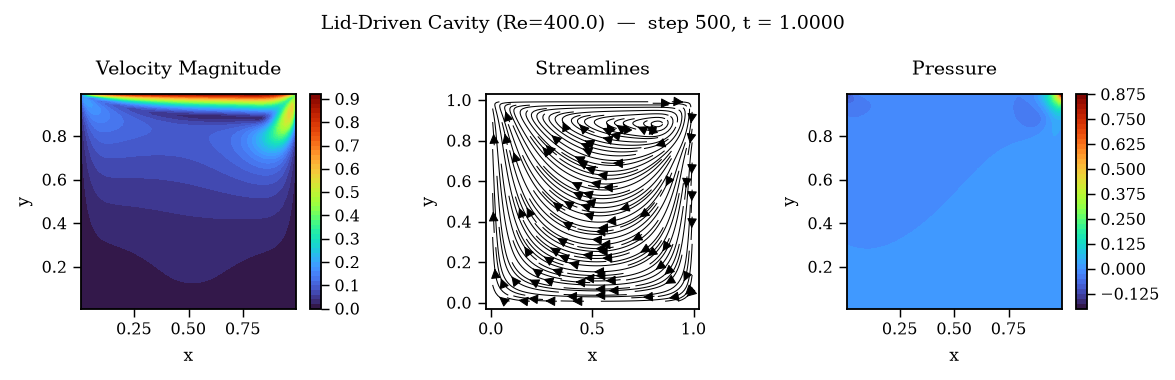

Plotted step 500/5000  |u|_max = 0.901060


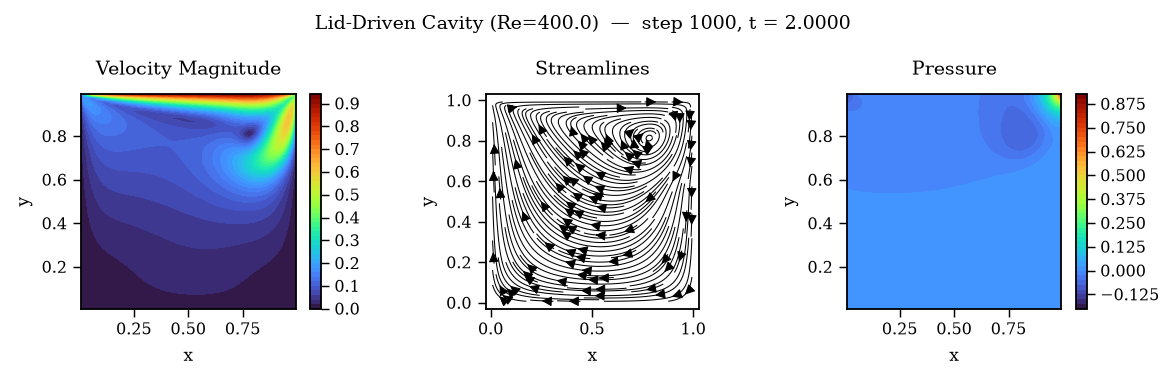

Plotted step 1000/5000  |u|_max = 0.920712


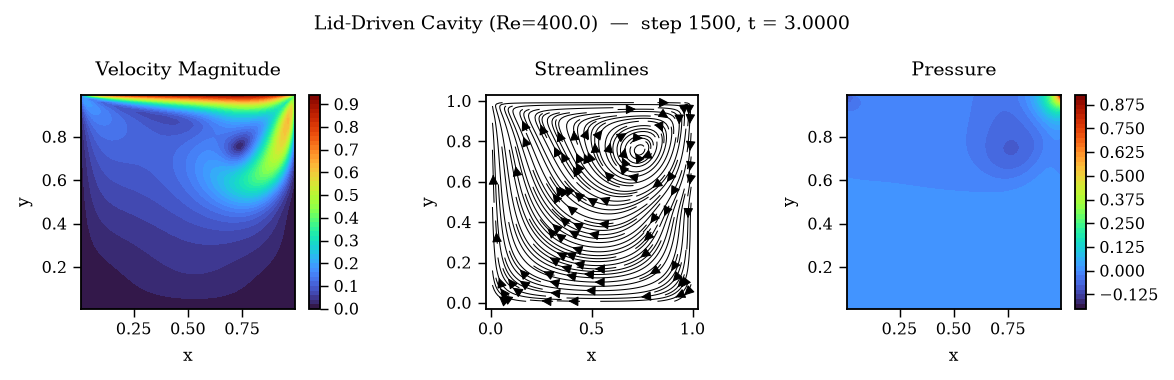

Plotted step 1500/5000  |u|_max = 0.920818


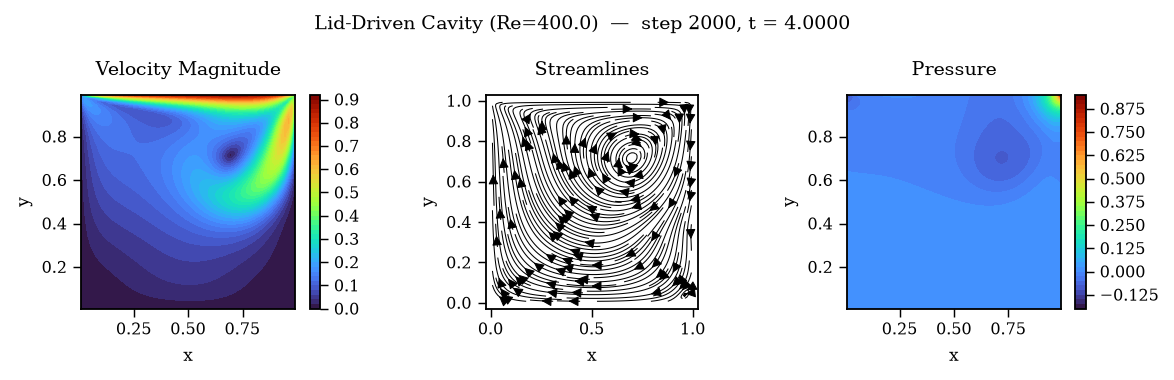

Plotted step 2000/5000  |u|_max = 0.919787


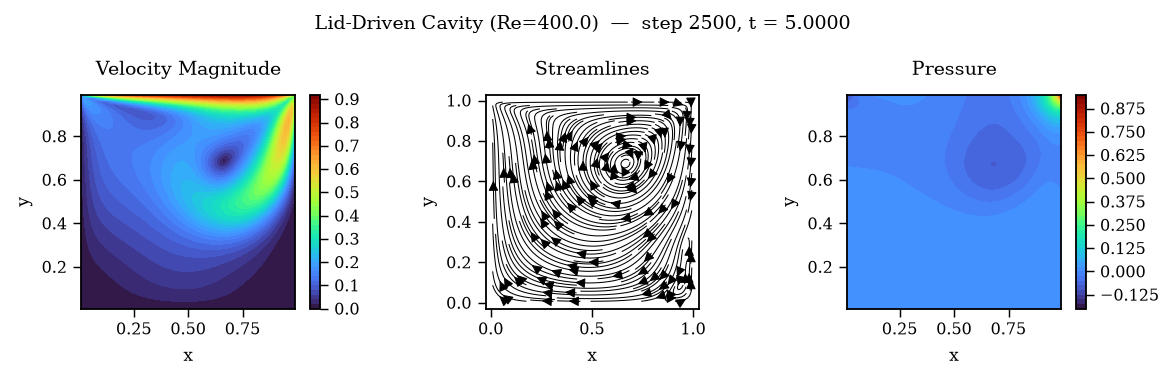

Plotted step 2500/5000  |u|_max = 0.919401


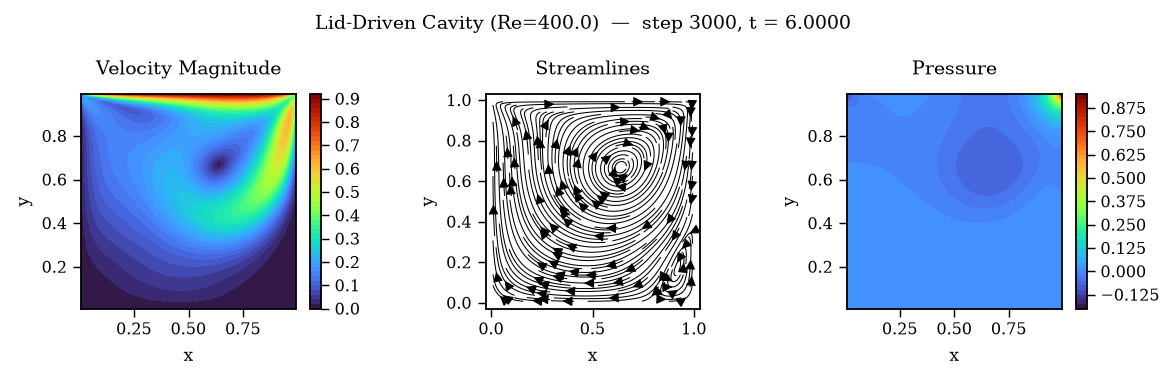

Plotted step 3000/5000  |u|_max = 0.919632


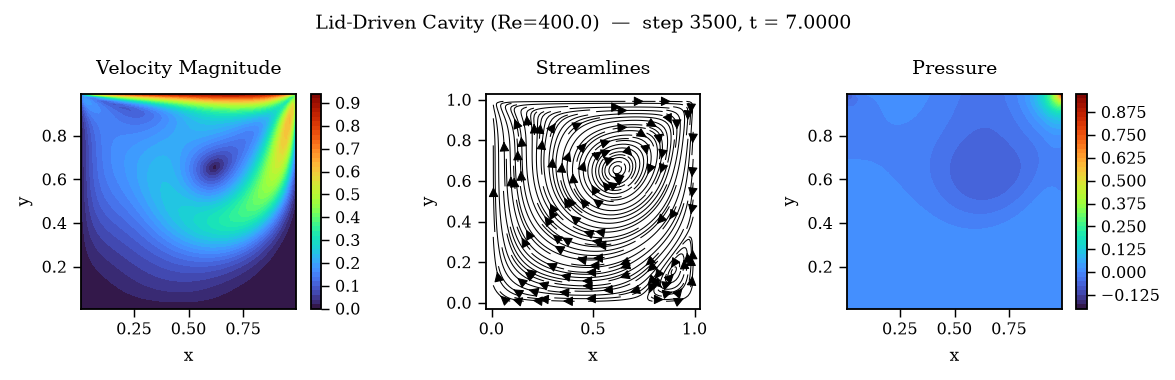

Plotted step 3500/5000  |u|_max = 0.920276


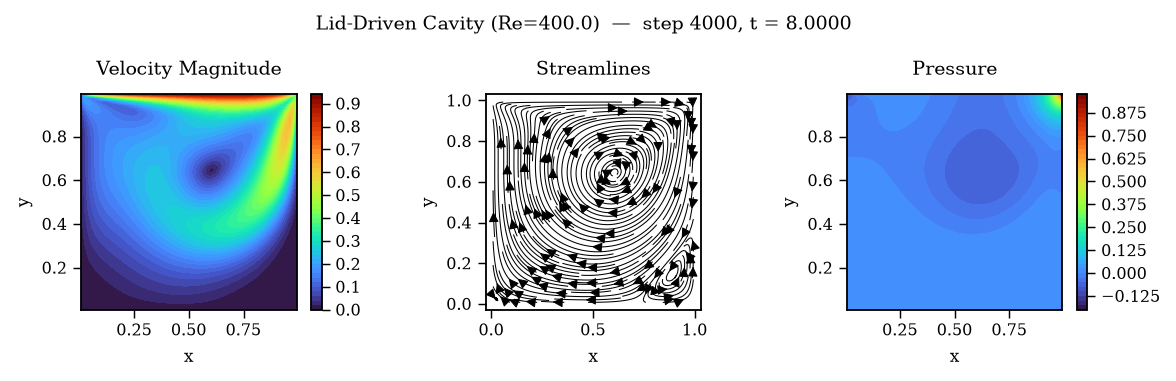

Plotted step 4000/5000  |u|_max = 0.921052


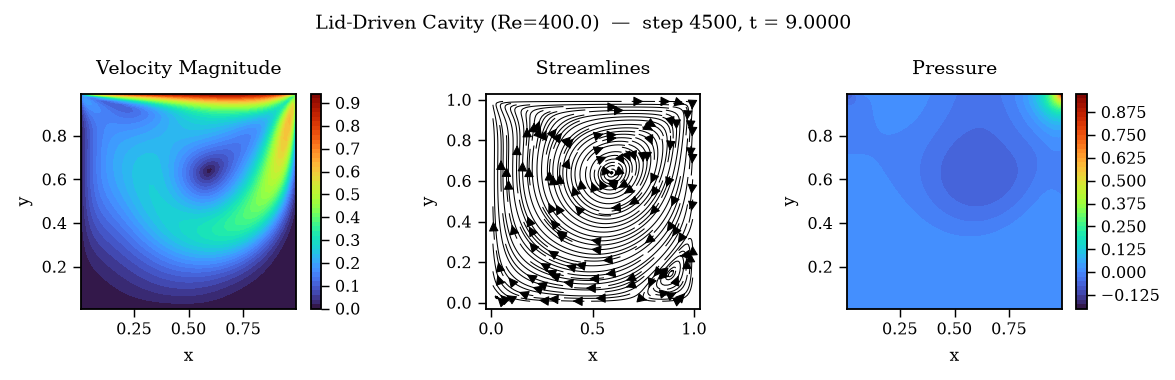

Plotted step 4500/5000  |u|_max = 0.921902


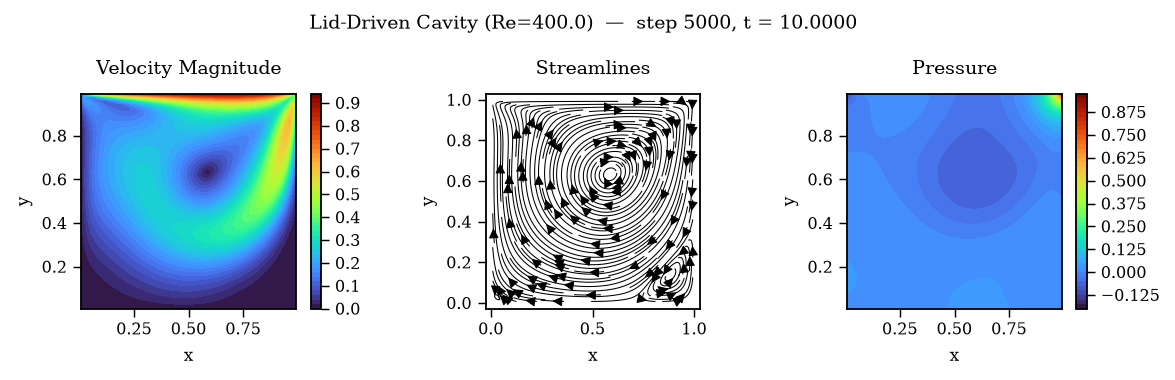

Plotted step 5000/5000  |u|_max = 0.922607


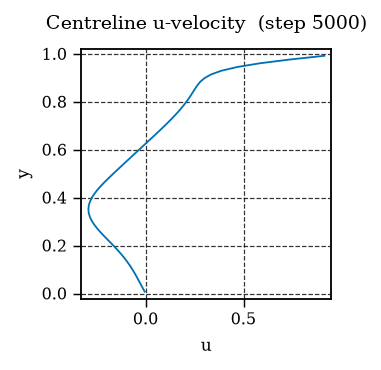

In [23]:
# Poll and plot every N-th exported dataset
Re = config_ldc["Re"]
plot_every = int(config_ldc["save_interval"] * 5)  # multiple of chunk_size

for step in range(config_ldc["save_interval"], config_ldc["nt"] + 1, config_ldc["save_interval"]):

    dataset_name = f"data_{step}"

    # Wait for the dataset to appear (timeout: 300 s, poll interval: 1000 ms)
    client.poll_dataset(dataset_name, 300, 1000)
    dataset = client.get_dataset(dataset_name)

    # Only plot at selected intervals (and always the final step)
    if step % plot_every == 0 or step == config_ldc["nt"]:
        u_c = dataset.get_tensor("u_centre")
        v_c = dataset.get_tensor("v_centre")
        speed = dataset.get_tensor("speed")
        p = dataset.get_tensor("p")
        sim_time = dataset.get_meta_scalars("sim_time")[0]

        plot_cavity_fields(step, sim_time, u_c, v_c, speed, p, config_ldc["nx"], config_ldc["ny"])

        print(f"Plotted step {step}/{config_ldc['nt']}  |u|_max = {speed.max():.6f}")

# Final centreline profile
plot_centreline(config_ldc["nt"], u_c, config_ldc["ny"])

# Use the Experiment API to wait until the model is finished
while not exp.finished(producer):
    time.sleep(5)

In [24]:
# Summarise the experiment results
print(exp.summary(style="rounded_grid"))

# Cleanup
print("\nExperiment completed. Cleaning up...")
exp.stop(db)
exp.stop(producer)
print("Done.")

╭────┬──────────┬───────────────┬─────────┬─────────┬────────┬─────────────────────────────────┬──────────────╮
│    │ Name     │ Entity-Type   │ JobID   │ RunID   │ Time   │ Status                          │ Returncode   │
├────┼──────────┼───────────────┼─────────┼─────────┼────────┼─────────────────────────────────┼──────────────┤
│ 0  │ producer │ Model         │ 2082145 │ 0       │ 9.8916 │ SmartSimStatus.STATUS_COMPLETED │ 0            │
╰────┴──────────┴───────────────┴─────────┴─────────┴────────┴─────────────────────────────────┴──────────────╯

Experiment completed. Cleaning up...
Done.
